In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

# ── Benchmark 1: Tipos de ID (batch 1000, trimmed mean) ──
b1 = pd.DataFrame([
    ("INT AUTO",  50000,  "baseline", 137973), ("INT AUTO",  50000,  "few", 102264),
    ("INT AUTO",  50000,  "medium",    81914), ("INT AUTO",  50000,  "many",  62776),
    ("INT AUTO",  200000, "baseline", 176995), ("INT AUTO",  200000, "few", 104547),
    ("INT AUTO",  200000, "medium",    92448), ("INT AUTO",  200000, "many",  61897),
    ("UUID v1",   50000,  "baseline",  94332), ("UUID v1",   50000,  "few",  87348),
    ("UUID v1",   50000,  "medium",    77771), ("UUID v1",   50000,  "many",  67222),
    ("UUID v1",   200000, "baseline", 120156), ("UUID v1",   200000, "few", 107216),
    ("UUID v1",   200000, "medium",    88486), ("UUID v1",   200000, "many",  59498),
    ("UUID v4",   50000,  "baseline",  43599), ("UUID v4",   50000,  "few",  68628),
    ("UUID v4",   50000,  "medium",    55549), ("UUID v4",   50000,  "many",  48433),
    ("UUID v4",   200000, "baseline",  94650), ("UUID v4",   200000, "few",  79295),
    ("UUID v4",   200000, "medium",    44104), ("UUID v4",   200000, "many",  18177),
    ("UUID v6",   50000,  "baseline",  94791), ("UUID v6",   50000,  "few",  83243),
    ("UUID v6",   50000,  "medium",    46854), ("UUID v6",   50000,  "many",  65858),
    ("UUID v6",   200000, "baseline", 111395), ("UUID v6",   200000, "few", 100555),
    ("UUID v6",   200000, "medium",    92672), ("UUID v6",   200000, "many",  59678),
    ("UUID v7",   50000,  "baseline",  93529), ("UUID v7",   50000,  "few",  81542),
    ("UUID v7",   50000,  "medium",    73528), ("UUID v7",   50000,  "many",  65113),
    ("UUID v7",   200000, "baseline",  92424), ("UUID v7",   200000, "few", 101835),
    ("UUID v7",   200000, "medium",    91601), ("UUID v7",   200000, "many",  57733),
    ("Snowflake", 50000,  "baseline", 132915), ("Snowflake", 50000,  "few", 107018),
    ("Snowflake", 50000,  "medium",    80191), ("Snowflake", 50000,  "many",  61202),
    ("Snowflake", 200000, "baseline", 164975), ("Snowflake", 200000, "few",  98341),
    ("Snowflake", 200000, "medium",    70568), ("Snowflake", 200000, "many",  57398),
], columns=["id_type", "rows", "scenario", "throughput"])

# ── Benchmark 2: Estratégias otimizadas ──
b2 = pd.DataFrame([
    ("INT AUTO",  200000, "baseline", "b100",      53107,  "executemany_b100"),
    ("INT AUTO",  200000, "baseline", "b1000",    183771,  "executemany_b1000"),
    ("INT AUTO",  200000, "baseline", "b5000",    202848,  "executemany_b5000"),
    ("INT AUTO",  200000, "baseline", "b10000",   200867,  "executemany_b10000"),
    ("INT AUTO",  200000, "baseline", "multi5k",  234018,  "multi_row_b5000"),
    ("INT AUTO",  200000, "many",     "b100",      33292,  "executemany_b100"),
    ("INT AUTO",  200000, "many",     "b1000",     48091,  "executemany_b1000"),
    ("INT AUTO",  200000, "many",     "b5000",     67864,  "executemany_b5000"),
    ("INT AUTO",  200000, "many",     "b10000",    54755,  "executemany_b10000"),
    ("INT AUTO",  200000, "many",     "multi5k",   67101,  "multi_row_b5000"),
    ("UUID v4",   200000, "baseline", "b100",      43478,  "executemany_b100"),
    ("UUID v4",   200000, "baseline", "b1000",     93526,  "executemany_b1000"),
    ("UUID v4",   200000, "baseline", "b5000",     98898,  "executemany_b5000"),
    ("UUID v4",   200000, "baseline", "b10000",    92363,  "executemany_b10000"),
    ("UUID v4",   200000, "baseline", "multi5k",  113312,  "multi_row_b5000"),
    ("UUID v4",   200000, "baseline", "sorted5k", 105438,  "sorted_b5000"),
    ("UUID v4",   200000, "baseline", "sort+mr",  111494,  "sorted_multi_b5000"),
    ("UUID v4",   200000, "many",     "b100",      10078,  "executemany_b100"),
    ("UUID v4",   200000, "many",     "b1000",     16358,  "executemany_b1000"),
    ("UUID v4",   200000, "many",     "b5000",     19262,  "executemany_b5000"),
    ("UUID v4",   200000, "many",     "b10000",    16707,  "executemany_b10000"),
    ("UUID v4",   200000, "many",     "multi5k",   12112,  "multi_row_b5000"),
    ("UUID v4",   200000, "many",     "sorted5k",  32811,  "sorted_b5000"),
    ("UUID v4",   200000, "many",     "sort+mr",   24343,  "sorted_multi_b5000"),
    ("UUID v7",   200000, "baseline", "b100",      46300,  "executemany_b100"),
    ("UUID v7",   200000, "baseline", "b1000",    112210,  "executemany_b1000"),
    ("UUID v7",   200000, "baseline", "b5000",    120262,  "executemany_b5000"),
    ("UUID v7",   200000, "baseline", "b10000",    91833,  "executemany_b10000"),
    ("UUID v7",   200000, "baseline", "multi5k",  123972,  "multi_row_b5000"),
    ("UUID v7",   200000, "many",     "b100",      37536,  "executemany_b100"),
    ("UUID v7",   200000, "many",     "b1000",     50547,  "executemany_b1000"),
    ("UUID v7",   200000, "many",     "b5000",     57674,  "executemany_b5000"),
    ("UUID v7",   200000, "many",     "b10000",    56720,  "executemany_b10000"),
    ("UUID v7",   200000, "many",     "multi5k",   63387,  "multi_row_b5000"),
    ("Snowflake", 200000, "baseline", "b100",      52422,  "executemany_b100"),
    ("Snowflake", 200000, "baseline", "b1000",    171168,  "executemany_b1000"),
    ("Snowflake", 200000, "baseline", "b5000",    183969,  "executemany_b5000"),
    ("Snowflake", 200000, "baseline", "b10000",   181277,  "executemany_b10000"),
    ("Snowflake", 200000, "baseline", "multi5k",  190107,  "multi_row_b5000"),
    ("Snowflake", 200000, "many",     "b100",      32080,  "executemany_b100"),
    ("Snowflake", 200000, "many",     "b1000",     56481,  "executemany_b1000"),
    ("Snowflake", 200000, "many",     "b5000",     66017,  "executemany_b5000"),
    ("Snowflake", 200000, "many",     "b10000",    46984,  "executemany_b10000"),
    ("Snowflake", 200000, "many",     "multi5k",   61177,  "multi_row_b5000"),
], columns=["id_type", "rows", "scenario", "strategy", "throughput", "strategy_full"])

COLORS = {
    "INT AUTO":  "#1f77b4",
    "UUID v1":   "#d62728",
    "UUID v4":   "#ff7f0e",
    "UUID v6":   "#9467bd",
    "UUID v7":   "#2ca02c",
    "Snowflake": "#17becf",
}

SCENARIOS = ["baseline", "few", "medium", "many"]
ID_TYPES = ["INT AUTO", "UUID v1", "UUID v4", "UUID v6", "UUID v7", "Snowflake"]

def fmt_k(v, _=None):
    return f"{v/1000:.0f}k"

✔ Dados carregados


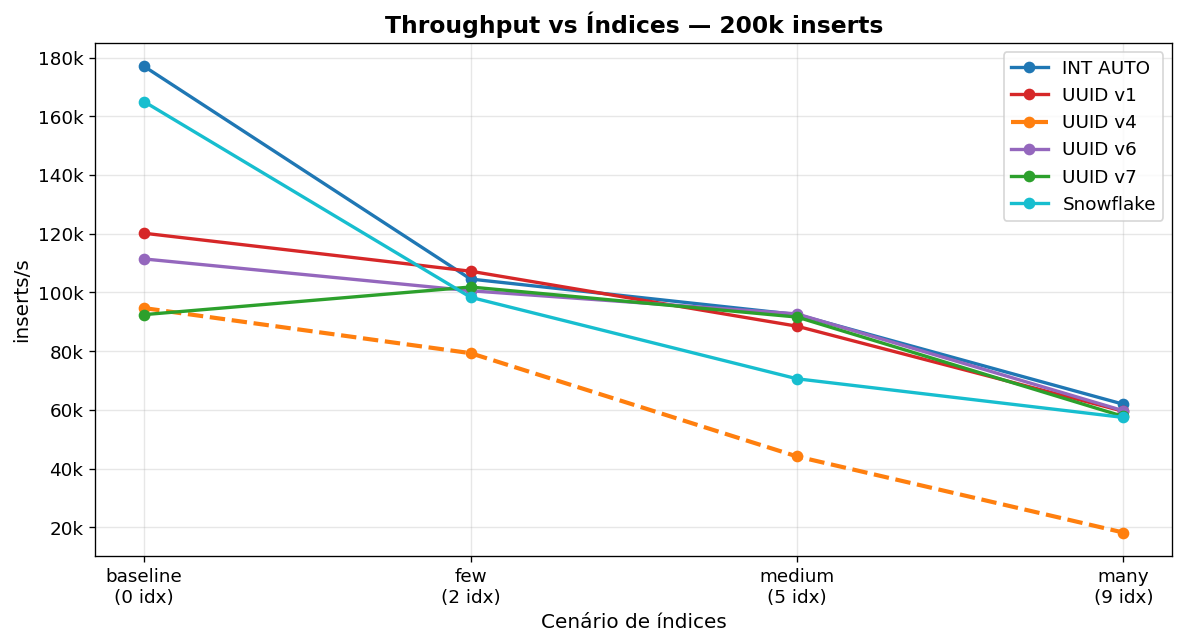

In [2]:
fig, ax = plt.subplots()
ax.set_title("Throughput vs Índices — 200k inserts")

df = b1[b1["rows"] == 200000]
x = np.arange(len(SCENARIOS))

for idt in ID_TYPES:
    sub = df[df["id_type"] == idt].set_index("scenario").reindex(SCENARIOS)
    style = {"linewidth": 2, "marker": "o", "markersize": 6, "color": COLORS[idt]}
    if idt == "UUID v4":
        style.update({"linestyle": "--", "linewidth": 2.5})
    ax.plot(x, sub["throughput"].values, label=idt, **style)

ax.set_xticks(x)
ax.set_xticklabels(["baseline\n(0 idx)", "few\n(2 idx)", "medium\n(5 idx)", "many\n(9 idx)"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.set_xlabel("Cenário de índices")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

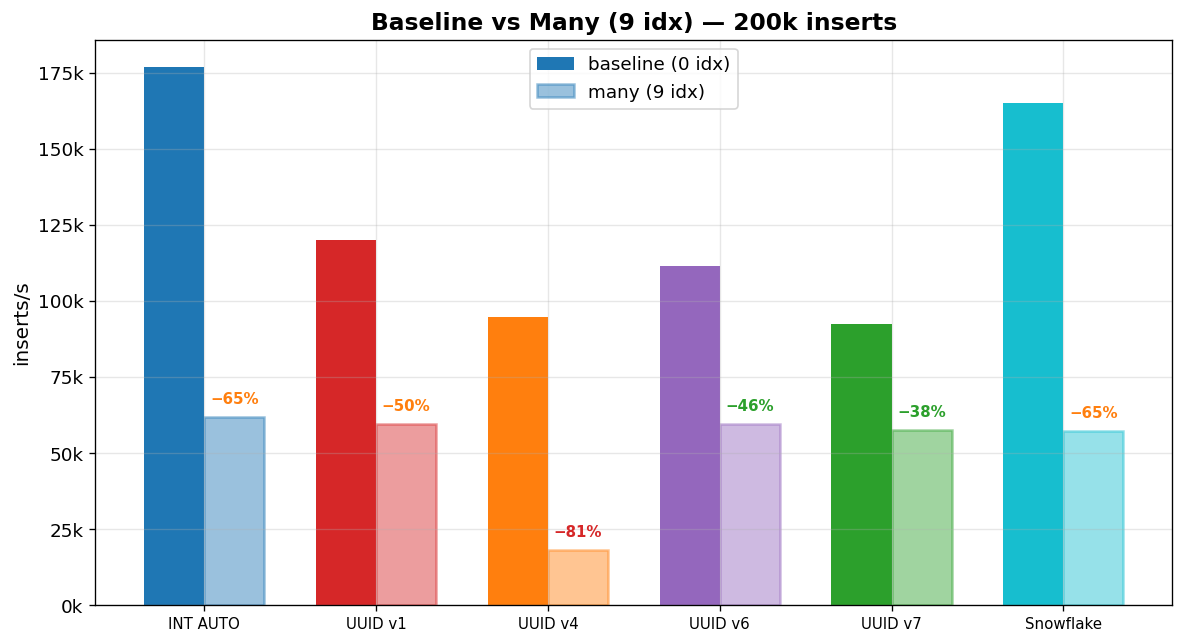

In [3]:
fig, ax = plt.subplots()
ax.set_title("Baseline vs Many (9 idx) — 200k inserts")

df = b1[b1["rows"] == 200000]
x = np.arange(len(ID_TYPES))
w = 0.35

base_vals = [df[(df["id_type"] == t) & (df["scenario"] == "baseline")]["throughput"].values[0] for t in ID_TYPES]
many_vals = [df[(df["id_type"] == t) & (df["scenario"] == "many")]["throughput"].values[0] for t in ID_TYPES]

ax.bar(x - w/2, base_vals, w, label="baseline (0 idx)", color=[COLORS[t] for t in ID_TYPES])
ax.bar(x + w/2, many_vals, w, label="many (9 idx)", color=[COLORS[t] for t in ID_TYPES], alpha=0.45,
       edgecolor=[COLORS[t] for t in ID_TYPES], linewidth=1.5)

for i in range(len(ID_TYPES)):
    drop = (base_vals[i] - many_vals[i]) / base_vals[i] * 100
    color = "#d62728" if drop > 70 else "#ff7f0e" if drop > 50 else "#2ca02c"
    ax.annotate(f"−{drop:.0f}%", xy=(x[i] + w/2, many_vals[i]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9, fontweight="bold", color=color)

ax.set_xticks(x)
ax.set_xticklabels(ID_TYPES, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.legend()
plt.tight_layout()
plt.show()

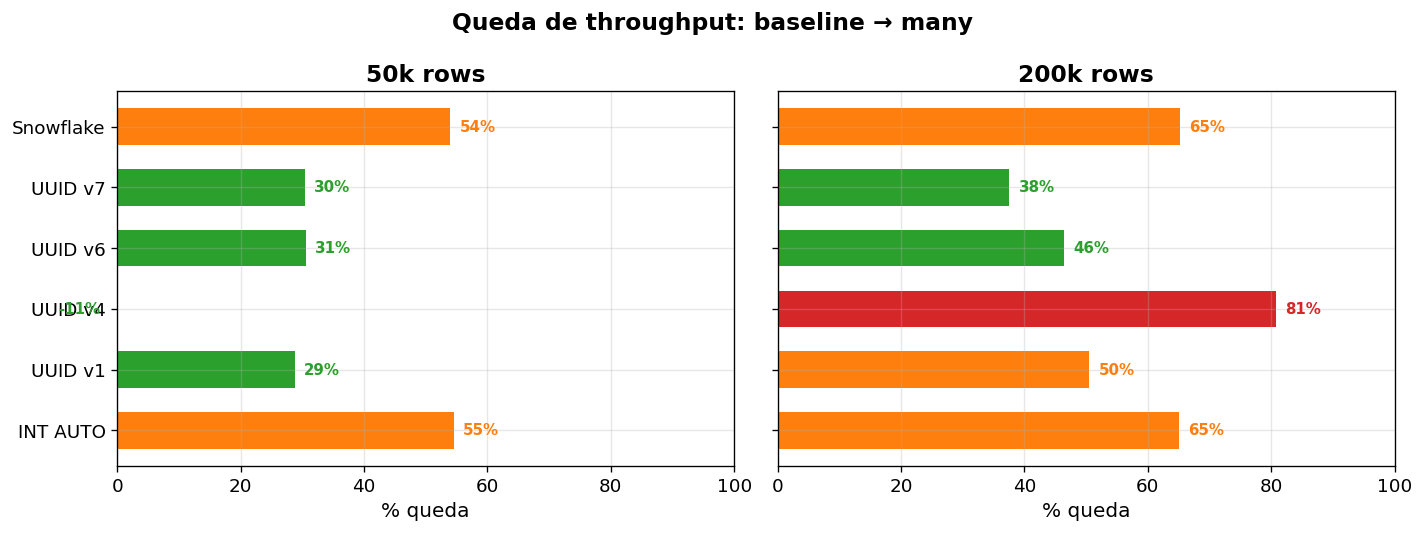

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
fig.suptitle("Queda de throughput: baseline → many", fontsize=14, fontweight="bold")

for ax, rows, title in zip(axes, [50000, 200000], ["50k rows", "200k rows"]):
    df = b1[b1["rows"] == rows]
    drops = []
    for t in ID_TYPES:
        base = df[(df["id_type"] == t) & (df["scenario"] == "baseline")]["throughput"].values[0]
        many = df[(df["id_type"] == t) & (df["scenario"] == "many")]["throughput"].values[0]
        drops.append((base - many) / base * 100)

    y = np.arange(len(ID_TYPES))
    bar_colors = ["#d62728" if d > 70 else "#ff7f0e" if d > 50 else "#2ca02c" for d in drops]

    ax.barh(y, drops, color=bar_colors, height=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(ID_TYPES)
    ax.set_xlabel("% queda")
    ax.set_title(title)
    ax.set_xlim(0, 100)

    for i, d in enumerate(drops):
        ax.text(d + 1.5, i, f"{d:.0f}%", va="center", fontsize=9, fontweight="bold", color=bar_colors[i])

plt.tight_layout()
plt.show()

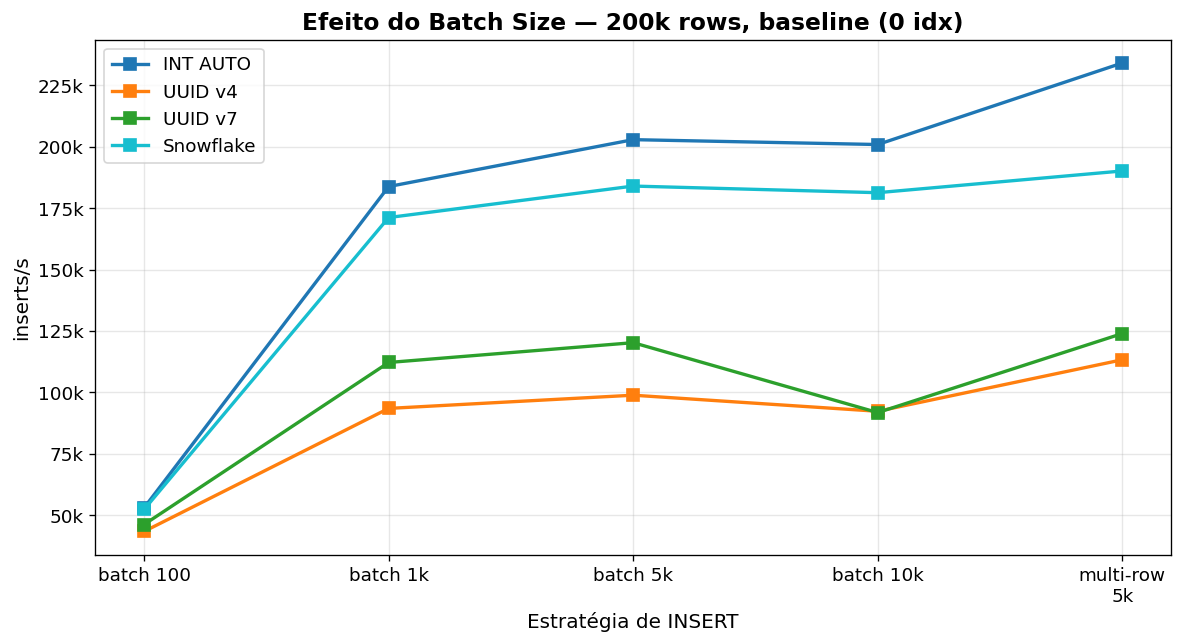

In [6]:
fig, ax = plt.subplots()
ax.set_title("Efeito do Batch Size — 200k rows, baseline (0 idx)")

strats = ["b100", "b1000", "b5000", "b10000", "multi5k"]
x_labels = ["batch 100", "batch 1k", "batch 5k", "batch 10k", "multi-row\n5k"]
x = np.arange(len(strats))

for idt in ["INT AUTO", "UUID v4", "UUID v7", "Snowflake"]:
    sub = b2[(b2["id_type"] == idt) & (b2["scenario"] == "baseline")]
    vals = [sub[sub["strategy"] == s]["throughput"].values[0] for s in strats]
    ax.plot(x, vals, color=COLORS[idt], linewidth=2, marker="s", markersize=7, label=idt)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.set_xlabel("Estratégia de INSERT")
ax.legend()
plt.tight_layout()
plt.show()

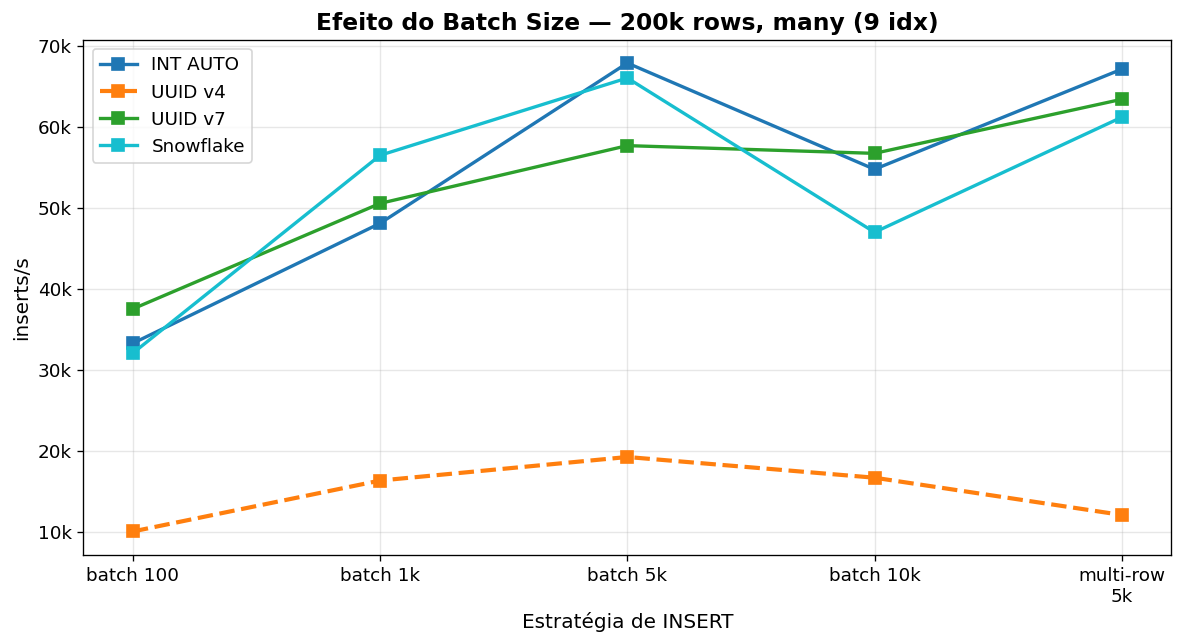

In [7]:
fig, ax = plt.subplots()
ax.set_title("Efeito do Batch Size — 200k rows, many (9 idx)")

for idt in ["INT AUTO", "UUID v4", "UUID v7", "Snowflake"]:
    sub = b2[(b2["id_type"] == idt) & (b2["scenario"] == "many")]
    vals = [sub[sub["strategy"] == s]["throughput"].values[0] for s in strats]
    ls = "--" if idt == "UUID v4" else "-"
    lw = 2.5 if idt == "UUID v4" else 2
    ax.plot(x, vals, color=COLORS[idt], linewidth=lw, linestyle=ls,
            marker="s", markersize=7, label=idt)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.set_xlabel("Estratégia de INSERT")
ax.legend()
plt.tight_layout()
plt.show()

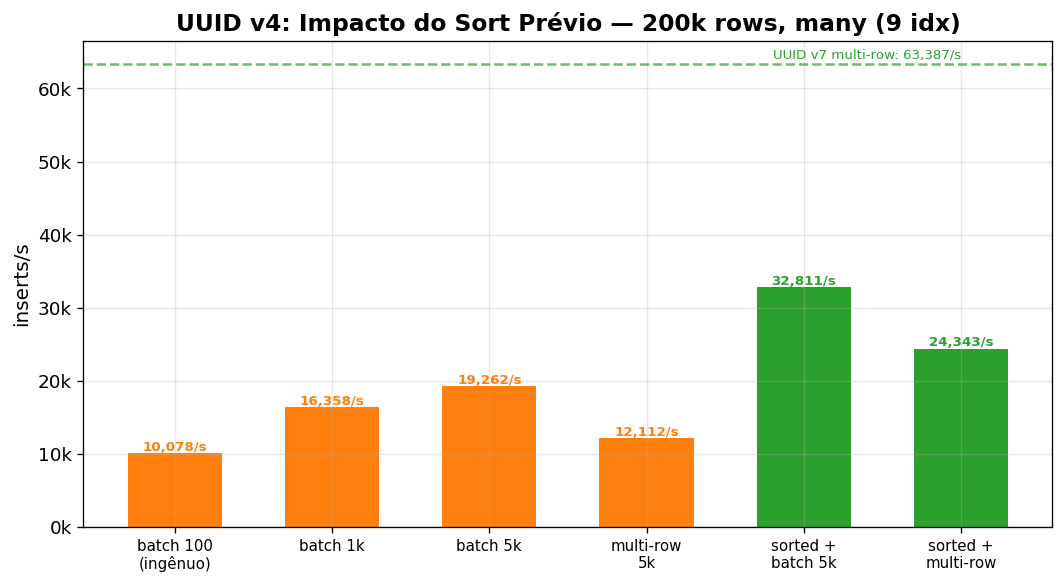

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title("UUID v4: Impacto do Sort Prévio — 200k rows, many (9 idx)")

v4_strats = [
    ("b100",      "batch 100\n(ingênuo)"),
    ("b1000",     "batch 1k"),
    ("b5000",     "batch 5k"),
    ("multi5k",   "multi-row\n5k"),
    ("sorted5k",  "sorted +\nbatch 5k"),
    ("sort+mr",   "sorted +\nmulti-row"),
]

sub = b2[(b2["id_type"] == "UUID v4") & (b2["scenario"] == "many")]
vals = [sub[sub["strategy"] == s[0]]["throughput"].values[0] for s in v4_strats]
labels = [s[1] for s in v4_strats]
bar_colors = ["#ff7f0e"] * 4 + ["#2ca02c"] * 2

ax.bar(range(len(vals)), vals, color=bar_colors, width=0.6)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")

for i, v in enumerate(vals):
    ax.text(i, v + 400, f"{v:,}/s", ha="center", fontsize=8, fontweight="bold", color=bar_colors[i])

# Referência: UUID v7 multi-row no mesmo cenário
v7_ref = b2[(b2["id_type"] == "UUID v7") & (b2["scenario"] == "many") &
            (b2["strategy"] == "multi5k")]["throughput"].values[0]
ax.axhline(y=v7_ref, color=COLORS["UUID v7"], linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(5, v7_ref + 800, f"UUID v7 multi-row: {v7_ref:,}/s", fontsize=8, color=COLORS["UUID v7"], ha="right")

plt.tight_layout()
plt.show()

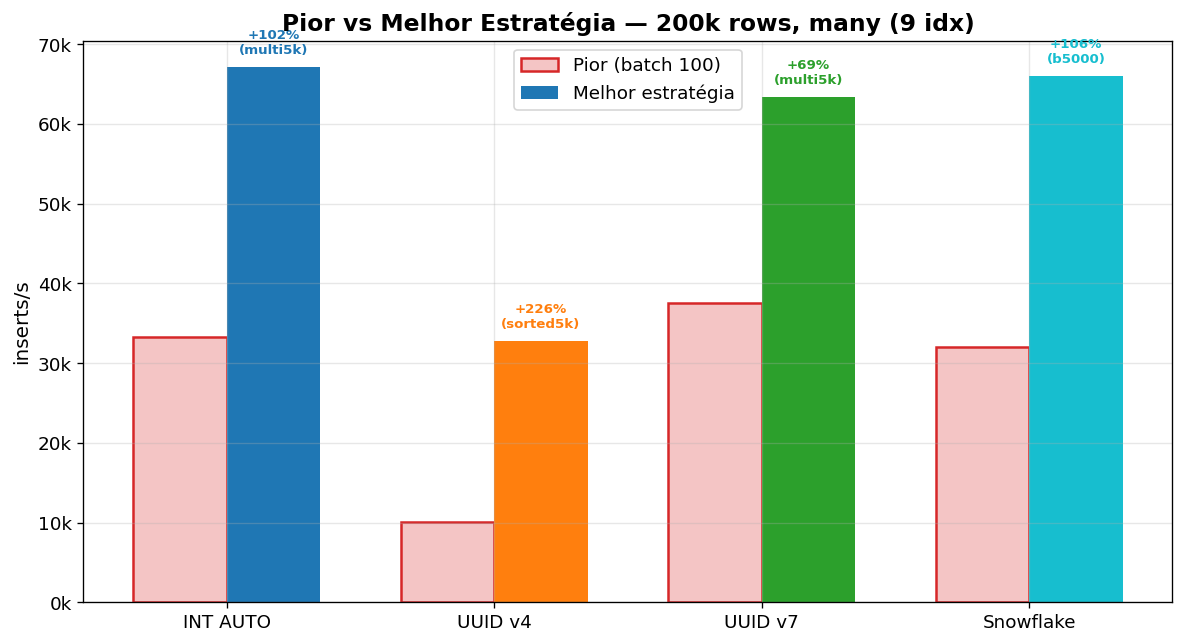

In [9]:
fig, ax = plt.subplots()
ax.set_title("Pior vs Melhor Estratégia — 200k rows, many (9 idx)")

types_show = ["INT AUTO", "UUID v4", "UUID v7", "Snowflake"]

worst = {t: b2[(b2["id_type"]==t) & (b2["scenario"]=="many") &
               (b2["strategy"]=="b100")]["throughput"].values[0] for t in types_show}

best_map = {"INT AUTO": "multi5k", "UUID v4": "sorted5k", "UUID v7": "multi5k", "Snowflake": "b5000"}
best = {t: b2[(b2["id_type"]==t) & (b2["scenario"]=="many") &
              (b2["strategy"]==best_map[t])]["throughput"].values[0] for t in types_show}

x = np.arange(len(types_show))
w = 0.35

ax.bar(x - w/2, [worst[t] for t in types_show], w,
       label="Pior (batch 100)", color="#d6272844", edgecolor="#d62728", linewidth=1.5)
ax.bar(x + w/2, [best[t] for t in types_show], w,
       label="Melhor estratégia", color=[COLORS[t] for t in types_show])

for i, t in enumerate(types_show):
    gain = (best[t] - worst[t]) / worst[t] * 100
    ax.annotate(f"+{gain:.0f}%\n({best_map[t]})", xy=(x[i] + w/2, best[t]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8, fontweight="bold", color=COLORS[t])

ax.set_xticks(x)
ax.set_xticklabels(types_show)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.legend()
plt.tight_layout()
plt.show()

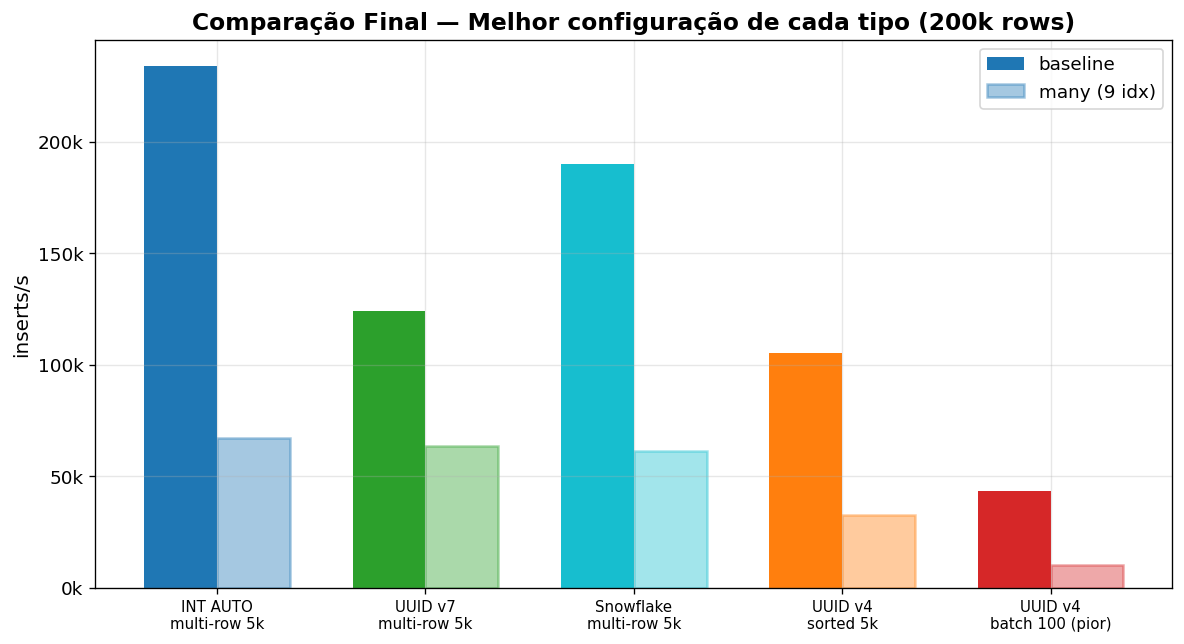

In [10]:
fig, ax = plt.subplots()
ax.set_title("Comparação Final — Melhor configuração de cada tipo (200k rows)")

configs = [
    ("INT AUTO\nmulti-row 5k",    234018, 67101,  COLORS["INT AUTO"]),
    ("UUID v7\nmulti-row 5k",     123972, 63387,  COLORS["UUID v7"]),
    ("Snowflake\nmulti-row 5k",   190107, 61177,  COLORS["Snowflake"]),
    ("UUID v4\nsorted 5k",        105438, 32811,  COLORS["UUID v4"]),
    ("UUID v4\nbatch 100 (pior)", 43478,  10078,  "#d62728"),
]

x = np.arange(len(configs))
w = 0.35

ax.bar(x - w/2, [c[1] for c in configs], w, label="baseline",
       color=[c[3] for c in configs])
ax.bar(x + w/2, [c[2] for c in configs], w, label="many (9 idx)",
       color=[c[3] for c in configs], alpha=0.4,
       edgecolor=[c[3] for c in configs], linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in configs], fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.legend()
plt.tight_layout()
plt.show()

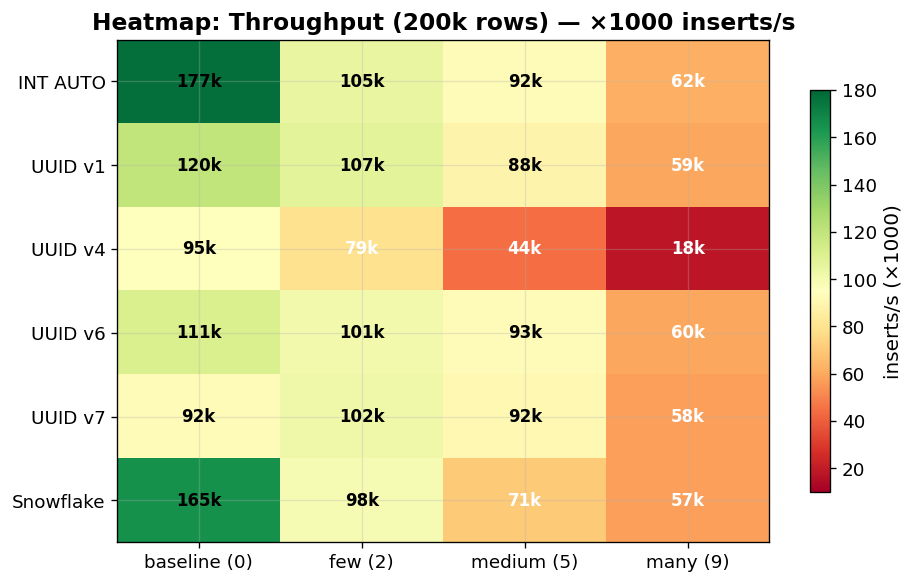

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title("Heatmap: Throughput (200k rows) — ×1000 inserts/s")

data = np.array([
    [b1[(b1["id_type"]==t) & (b1["rows"]==200000) & (b1["scenario"]==s)]["throughput"].values[0] / 1000
     for s in SCENARIOS]
    for t in ID_TYPES
])

im = ax.imshow(data, cmap="RdYlGn", aspect="auto", vmin=10, vmax=180)
ax.set_xticks(range(len(SCENARIOS)))
ax.set_xticklabels(["baseline (0)", "few (2)", "medium (5)", "many (9)"])
ax.set_yticks(range(len(ID_TYPES)))
ax.set_yticklabels(ID_TYPES)

for i in range(len(ID_TYPES)):
    for j in range(len(SCENARIOS)):
        val = data[i, j]
        color = "black" if val > 80 else "white"
        ax.text(j, i, f"{val:.0f}k", ha="center", va="center",
                fontsize=10, fontweight="bold", color=color)

fig.colorbar(im, ax=ax, label="inserts/s (×1000)", shrink=0.8)
plt.tight_layout()
plt.show()